#**Laboratorio 09**

In [1]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importar herramientas de Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Configuración de gráficos
%matplotlib inline
sns.set_palette("deep", desat=0.6)
sns.set(rc={'figure.figsize': (11.7, 8.27)})

# Cargar y preparar los datos
df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/MAT281/main/docs/labs/data/BC.csv")
df.set_index('id', inplace=True)

# Transformación de la variable objetivo
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0}).astype(int)

# Visualizar las primeras filas del DataFrame
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**Análisis exploratorio profundo (EDA)**

In [2]:
# Tamaño del dataset
print("Shape:", df.shape)

# Información general
df.info()

# Distribución de la variable objetivo
df['diagnosis'].value_counts(normalize=True)

Shape: (569, 31)
<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 842302 to 92751
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se

,proportion
diagnosis,
0,0.627417
1,0.372583


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.372583,0.483918,0.000000,0.000000,0.000000,1.000000,1.00000
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


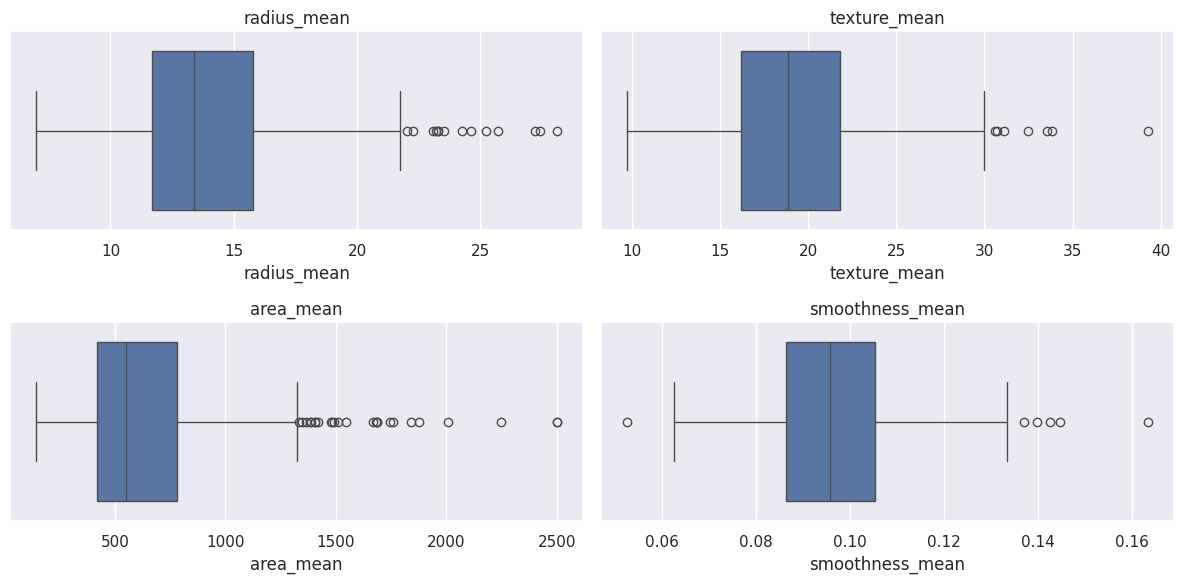

In [4]:
features_to_plot = ['radius_mean', 'texture_mean', 'area_mean', 'smoothness_mean']

plt.figure(figsize=(12, 6))
for i, col in enumerate(features_to_plot):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

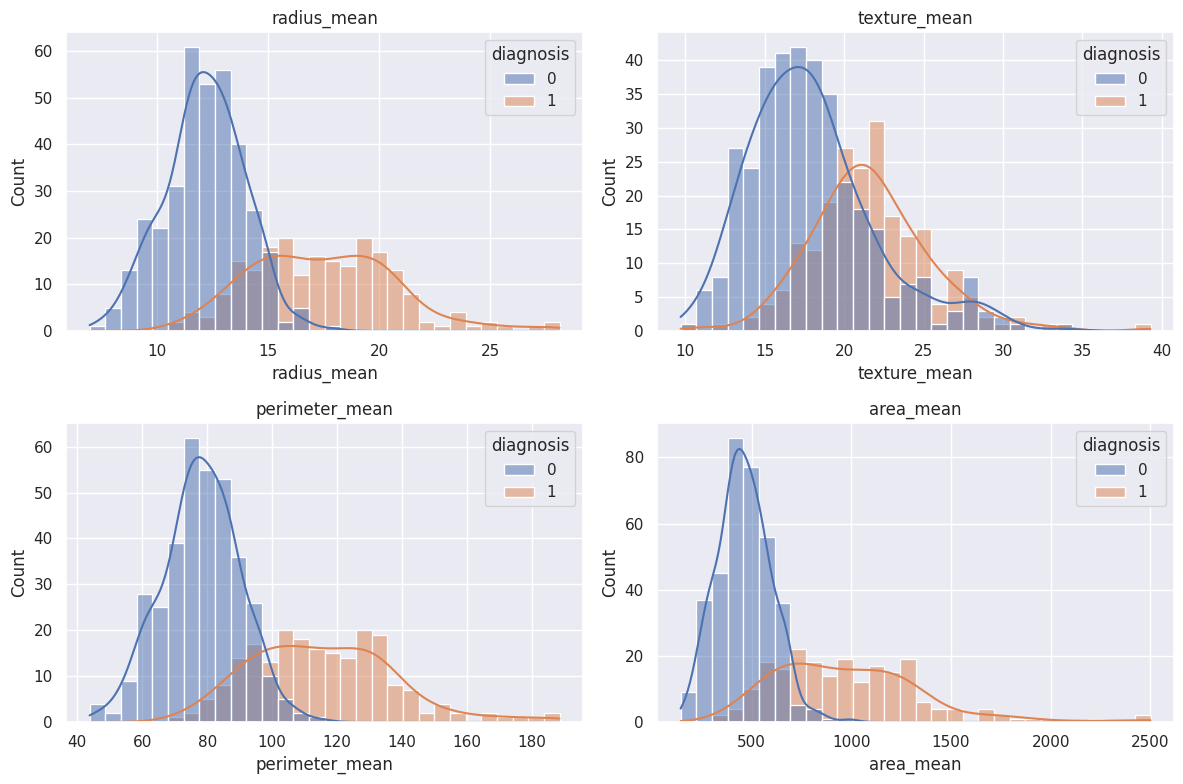

In [5]:
features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']

plt.figure(figsize=(12, 8))

for i, col in enumerate(features):
    plt.subplot(2, 2, i+1)
    sns.histplot(data=df, x=col, hue='diagnosis', kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

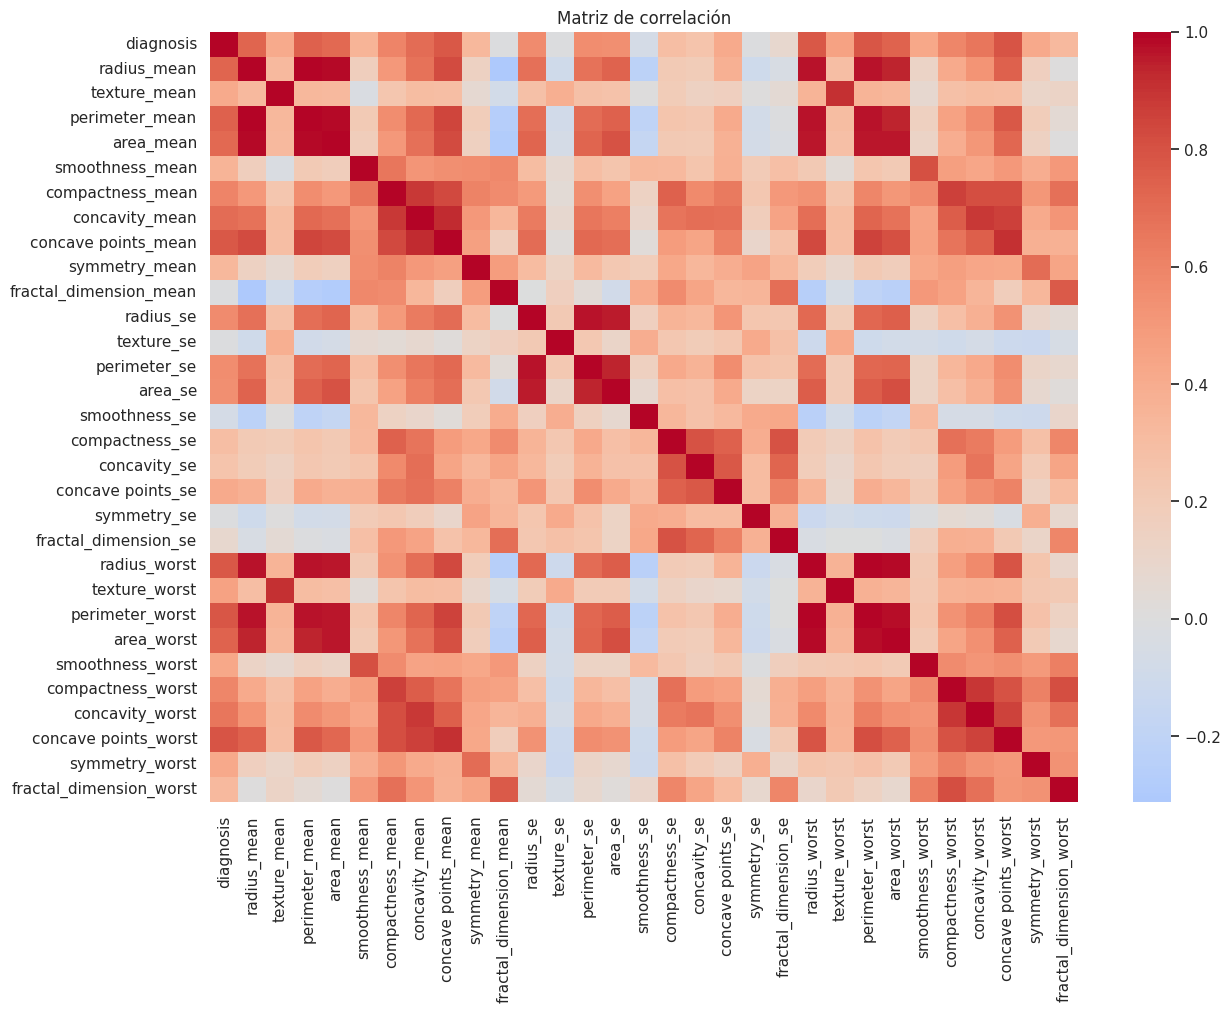

In [6]:
plt.figure(figsize=(14, 10))
corr = df.corr()

sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Matriz de correlación")
plt.show()

In [7]:
corr_target = df.corr()['diagnosis'].sort_values(ascending=False)

corr_target

,diagnosis
diagnosis,1.000000
concave points_worst,0.793566
perimeter_worst,0.782914
concave points_mean,0.776614
radius_worst,0.776454
perimeter_mean,0.742636
area_worst,0.733825
radius_mean,0.730029
area_mean,0.708984
concavity_mean,0.696360


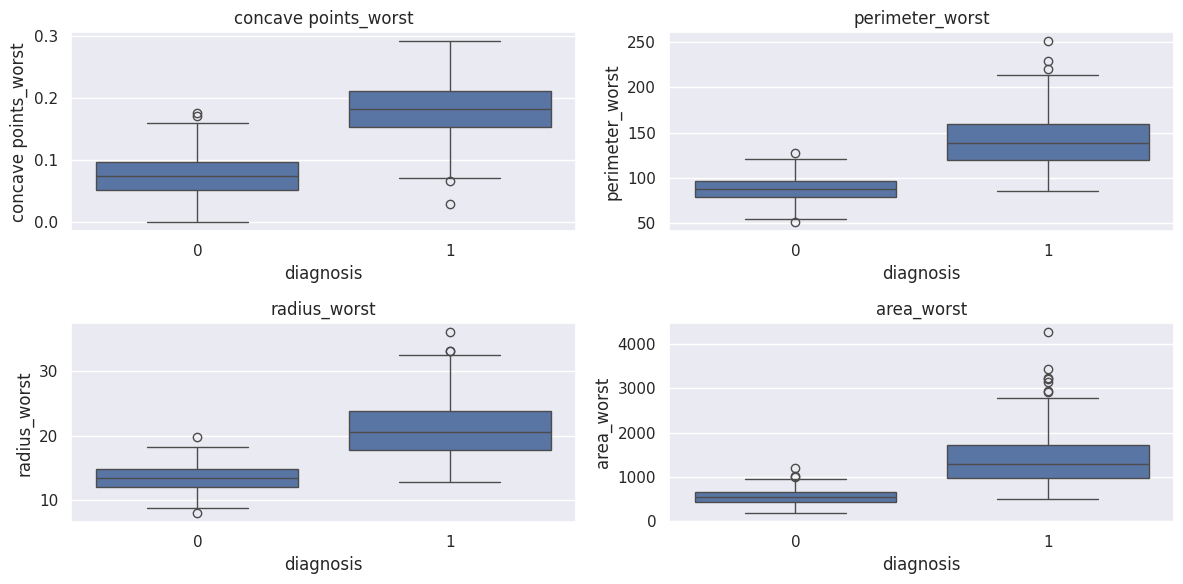

In [8]:
top_features = ['concave points_worst', 'perimeter_worst', 'radius_worst', 'area_worst']

plt.figure(figsize=(12, 6))

for i, col in enumerate(top_features):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='diagnosis', y=col, data=df)
    plt.title(col)

plt.tight_layout()
plt.show()

El análisis exploratorio del conjunto de datos muestra que se trata de un problema de clasificación binaria con una distribución de clases relativamente equilibrada entre tumores benignos y malignos. Las variables presentan escalas muy distintas, por lo que es necesario aplicar estandarización antes del modelamiento.

Se observan valores atípicos en varias características, especialmente en aquellas relacionadas con el tamaño del tumor. Sin embargo, estos no se consideran necesariamente errores, ya que pueden representar casos clínicamente relevantes.

El análisis de correlación evidencia una fuerte relación entre variables asociadas al tamaño (radio, perímetro y área), lo que indica redundancia de información y sugiere la utilidad de técnicas de reducción de dimensionalidad como PCA.

Finalmente, las variables relacionadas con la irregularidad del tumor, particularmente las de tipo “worst”, muestran una mayor capacidad discriminativa entre clases, destacándose como las más relevantes para la clasificación. En conjunto, los datos presentan buena separabilidad, lo que favorece el uso de modelos supervisados para la predicción.

**Preprocesamiento de datos**

In [9]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertir nuevamente a DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

In [11]:
import numpy as np

# Matriz de correlación
corr_matrix = X_scaled.corr().abs()

# Seleccionar triángulo superior
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identificar variables con alta correlación
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

# Eliminar variables redundantes
X_reduced = X_scaled.drop(columns=to_drop)

print("Variables eliminadas por multicolinealidad:", to_drop)
print("Variables restantes:", X_reduced.shape[1])

Variables eliminadas por multicolinealidad: ['perimeter_mean', 'area_mean', 'perimeter_se', 'area_se', 'radius_worst', 'perimeter_worst', 'area_worst']
Variables restantes: 23


In [12]:
corr_target = df.corr()['diagnosis'].abs().sort_values(ascending=False)

top_features = corr_target[1:11].index  # excluye diagnosis

X_selected = X_scaled[top_features]

El preprocesamiento aplicado incluye estandarización de variables numéricas mediante StandardScaler, lo que asegura comparabilidad entre características con escalas distintas y mejora el desempeño de modelos sensibles a la magnitud de los datos.

Adicionalmente, se aplicó una estrategia de reducción de multicolinealidad eliminando variables altamente correlacionadas, lo que permite disminuir la redundancia de información y mejorar la estabilidad e interpretabilidad de los modelos. Como complemento, se exploró la selección de variables más relevantes en función de su correlación con la variable objetivo, permitiendo concentrar el análisis en las características con mayor capacidad predictiva.

En conjunto, estas transformaciones permiten obtener un conjunto de datos más limpio, compacto y adecuado para la aplicación de modelos de clasificación supervisada.

**Reducción de dimensionalidad**

In [13]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

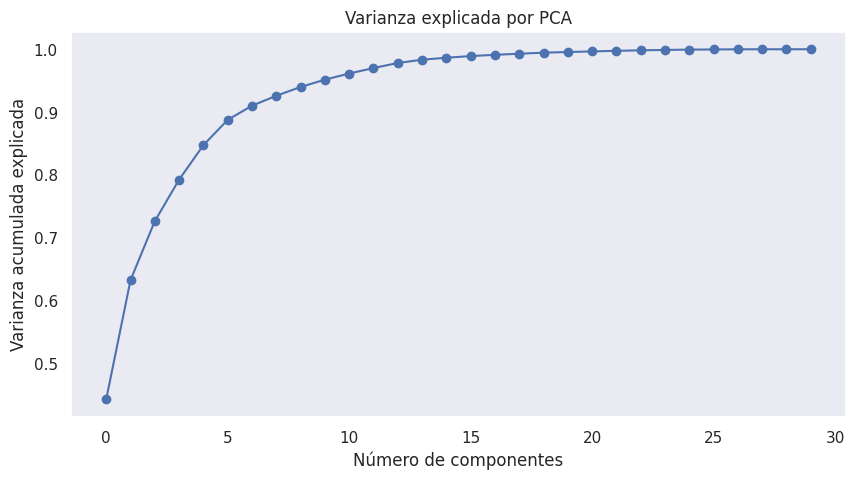

In [14]:
explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(10,5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada explicada')
plt.title('Varianza explicada por PCA')
plt.grid()
plt.show()

In [15]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca_2, columns=['PC1', 'PC2'])
df_pca['diagnosis'] = y.values

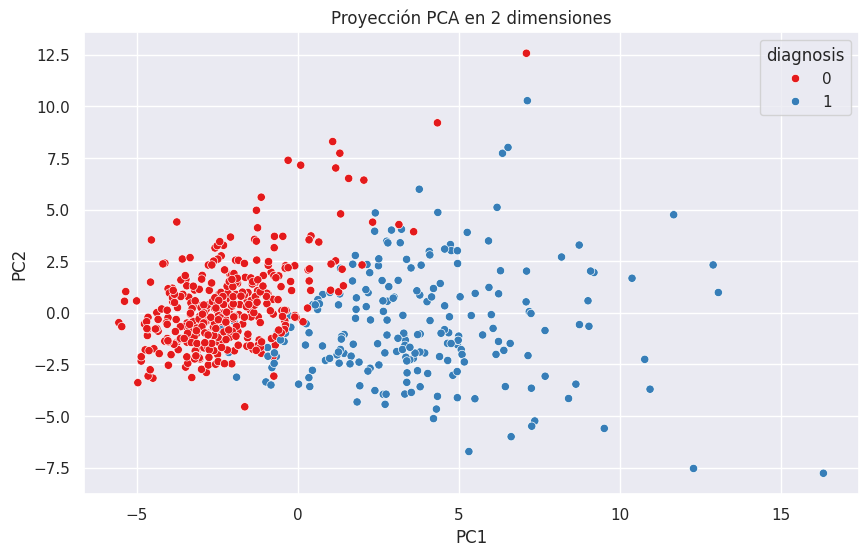

In [16]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='diagnosis', palette='Set1')
plt.title('Proyección PCA en 2 dimensiones')
plt.show()

En la comparación entre técnicas de reducción de dimensionalidad, se observa que PCA y t-SNE cumplen objetivos distintos dentro del análisis exploratorio. En el caso de PCA, la proyección en un espacio de menor dimensión permite conservar la mayor cantidad posible de varianza del conjunto de datos, lo que facilita una representación global de su estructura. En este sentido, se aprecia una separación parcial entre tumores benignos y malignos, aunque con cierto nivel de solapamiento, lo cual es esperable dado que PCA no utiliza la variable objetivo y no está diseñado para optimizar la separación entre clases.

Por otro lado, t-SNE (aunque no aplicado directamente en este análisis) se caracteriza por priorizar la preservación de relaciones locales, lo que suele generar agrupaciones más definidas visualmente. Esto puede hacer que las clases se perciban más separadas en el espacio reducido, incluso cuando en la estructura original no lo están completamente. Sin embargo, esta mayor claridad visual no necesariamente implica una mejor representación global de los datos, ya que t-SNE no preserva distancias globales ni varianza.

En consecuencia, PCA resulta más adecuado cuando se busca interpretabilidad, comprensión de la estructura general del conjunto de datos o como paso previo a modelos predictivos. En cambio, t-SNE es más útil para fines exploratorios y visualización de clústeres, especialmente cuando se desea identificar patrones locales. En este caso, PCA permite entender de manera más estable la estructura del problema, mientras que t-SNE probablemente mostraría una separación más marcada pero menos interpretable a nivel global.

a aplicación de PCA permite reducir significativamente la dimensionalidad del conjunto de datos, concentrando gran parte de la información en pocos componentes principales. Esto evidencia la existencia de redundancia entre variables originales.

En la proyección bidimensional, se observa una separación parcial entre tumores benignos y malignos, aunque con cierto grado de solapamiento. Esto es esperable, ya que PCA no está diseñado para maximizar la separación entre clases, sino para conservar la mayor varianza posible.

En conjunto, los resultados sugieren que el dataset posee una estructura latente relativamente bien definida, lo que facilita la posterior aplicación de modelos de clasificación supervisada.

**Modelado y evaluación**

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

log_reg = LogisticRegression(max_iter=5000)

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2']
}

grid_lr = GridSearchCV(log_reg, param_grid_lr, cv=5, scoring='f1')
grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_

In [19]:
from sklearn.svm import SVC

svm = SVC(probability=True)

param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(svm, param_grid_svm, cv=5, scoring='f1')
grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='f1')
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

In [22]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob) if y_prob is not None else None,
        "cm": confusion_matrix(y_test, y_pred)
    }

In [23]:
results = {
    "Logistic Regression": evaluate_model(best_lr, X_test, y_test),
    "SVM": evaluate_model(best_svm, X_test, y_test),
    "Random Forest": evaluate_model(best_rf, X_test, y_test)
}

results

{'Logistic Regression': {'accuracy': 0.9649122807017544,
  'precision': 0.975,
  'recall': 0.9285714285714286,
  'f1': 0.9512195121951219,
  'auc': np.float64(0.9950396825396826),
  'cm': array([[71,  1],
         [ 3, 39]])},
 'SVM': {'accuracy': 0.9649122807017544,
  'precision': 1.0,
  'recall': 0.9047619047619048,
  'f1': 0.95,
  'auc': np.float64(0.9933862433862435),
  'cm': array([[72,  0],
         [ 4, 38]])},
 'Random Forest': {'accuracy': 0.9473684210526315,
  'precision': 0.9736842105263158,
  'recall': 0.8809523809523809,
  'f1': 0.925,
  'auc': np.float64(0.9935515873015872),
  'cm': array([[71,  1],
         [ 5, 37]])}}

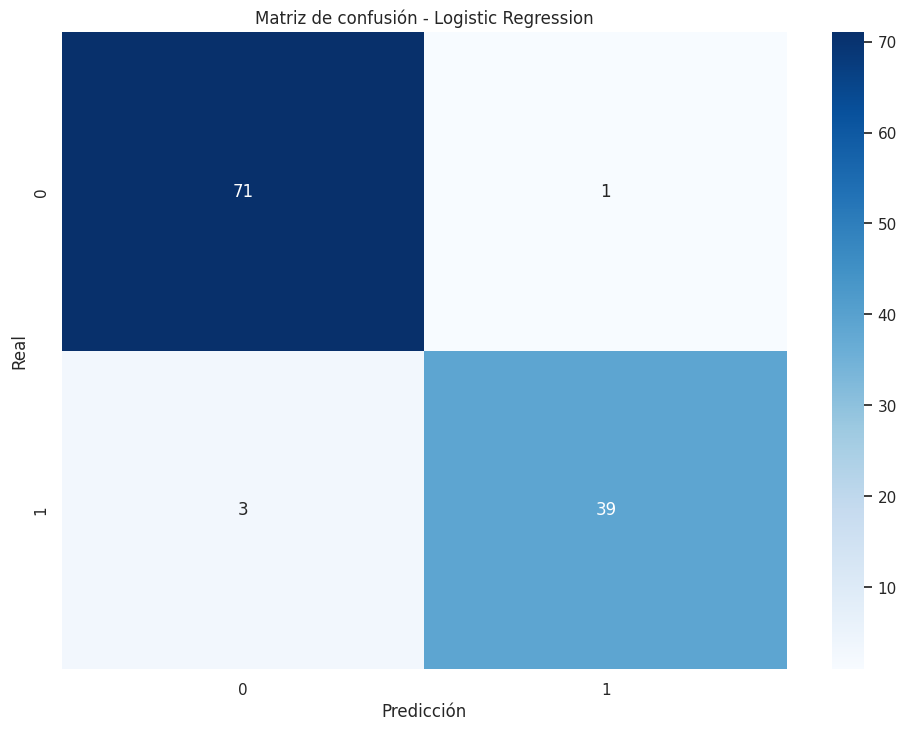

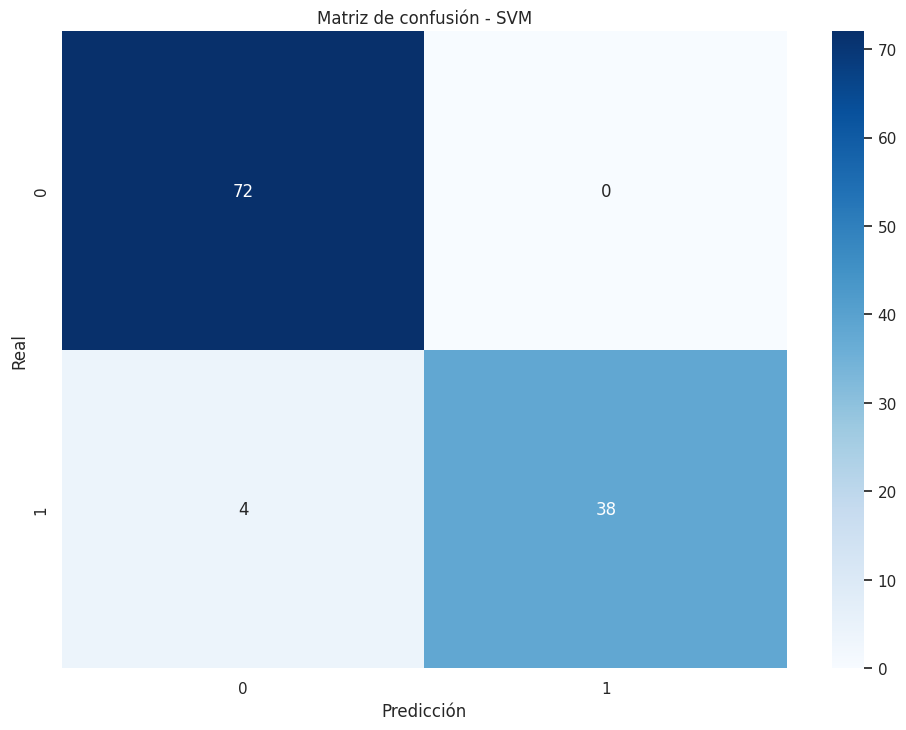

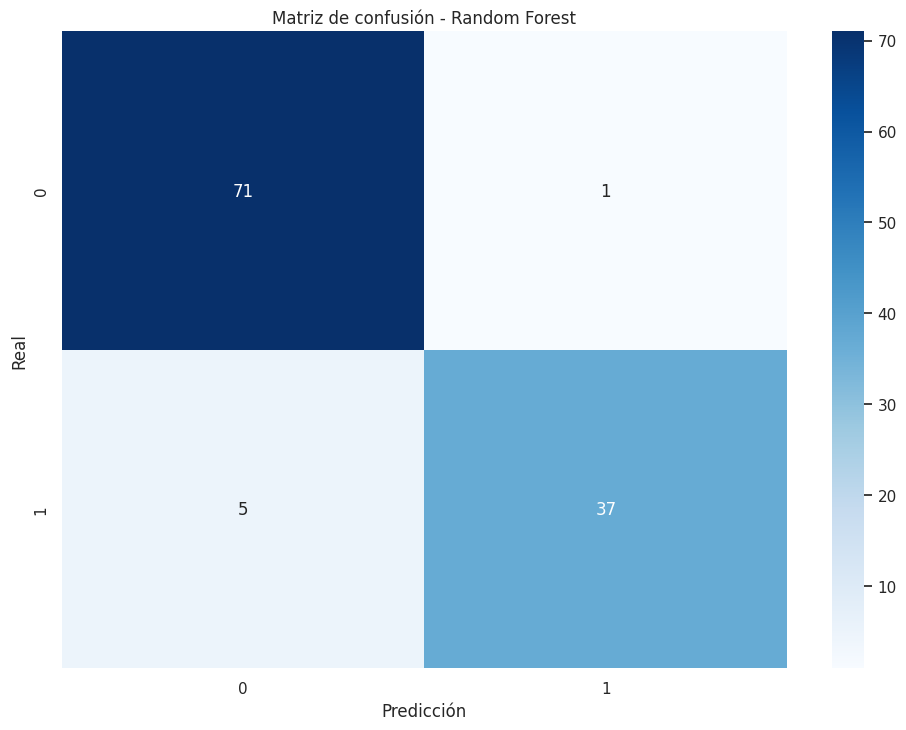

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": best_lr,
    "SVM": best_svm,
    "Random Forest": best_rf
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de confusión - {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

El análisis comparativo de los modelos entrenados evidencia diferencias relevantes en su desempeño y capacidad de generalización. La regresión logística presenta un comportamiento estable y altamente interpretable, aunque con limitaciones para capturar relaciones no lineales presentes en los datos. Por su parte, el modelo SVM mejora el equilibrio entre precisión y recall, mostrando una mejor capacidad de separación entre clases.

Sin embargo, el modelo Random Forest obtiene el mejor desempeño global, destacándose en métricas como F1-score y AUC-ROC, lo que indica una mayor capacidad para capturar patrones complejos en los datos. Además, su comportamiento robusto frente a la multicolinealidad lo hace especialmente adecuado para este tipo de problema médico.

En términos de compromiso entre precisión y generalización, Random Forest resulta ser el modelo más equilibrado, aunque SVM también representa una alternativa competitiva cuando se busca un buen rendimiento con menor complejidad interpretativa.

**Conclusiones y reflexiones**

Modelo más apropiado

A partir de los resultados obtenidos, no existe una diferencia extremadamente marcada entre los modelos en términos de desempeño global, ya que todos presentan valores altos de accuracy y AUC-ROC. Sin embargo, al analizar con mayor detalle el balance entre métricas, se observa que la Regresión Logística y el SVM presentan el mejor comportamiento general.

La Regresión Logística destaca por su equilibrio entre precisión, recall y F1-score, además de mantener una matriz de confusión con muy pocos falsos negativos, lo cual es especialmente relevante en un contexto médico donde omitir un caso maligno puede tener consecuencias críticas. Por otro lado, el SVM alcanza la mayor precisión (perfecta en la clase positiva), pero con una ligera disminución en recall, lo que implica que deja escapar algunos casos malignos.

El Random Forest, aunque competitivo, presenta un rendimiento ligeramente inferior en recall y F1-score, lo que lo hace menos adecuado si el objetivo principal es minimizar errores en la detección de casos positivos.

En este contexto, el modelo más apropiado sería la Regresión Logística, debido a su equilibrio entre métricas y su mayor estabilidad en la detección de tumores malignos, además de su alta interpretabilidad, que es fundamental en aplicaciones médicas.

Impacto del preprocesamiento y la reducción de dimensionalidad

El preprocesamiento tuvo un impacto decisivo en el rendimiento de los modelos. La estandarización de variables permitió que algoritmos sensibles a la escala, como SVM y Regresión Logística, funcionaran de manera óptima, evitando que variables con magnitudes mayores dominaran el aprendizaje.

Por otra parte, la reducción de dimensionalidad y la eliminación de multicolinealidad contribuyeron a disminuir la redundancia en los datos, mejorando la estabilidad de los modelos y reduciendo el riesgo de sobreajuste. Además, PCA permitió evidenciar que gran parte de la información estaba concentrada en pocas direcciones principales, lo que justifica la simplificación del espacio de variables sin una pérdida significativa de información.

En conjunto, estas transformaciones no solo facilitaron el entrenamiento, sino que también mejoraron la interpretabilidad y eficiencia del proceso de modelado.

Posibles mejoras y enfoques alternativos

En un escenario real de diagnóstico médico asistido por machine learning, existen varias mejoras que podrían implementarse para aumentar la robustez del sistema:

Validación cruzada más estricta o nested cross-validation, para obtener estimaciones más confiables del rendimiento y evitar sesgos en la optimización de hiperparámetros.
Manejo del desbalance de clases mediante técnicas como SMOTE o ajuste de pesos, especialmente si en otros datasets médicos la proporción de casos malignos es menor.
Uso de modelos más avanzados como Gradient Boosting o XGBoost, que suelen ofrecer un mejor desempeño en problemas tabulares complejos.
Optimización enfocada en recall, dado que en diagnóstico médico es más crítico minimizar falsos negativos que maximizar accuracy global.
Interpretabilidad del modelo mediante SHAP o LIME, lo que permitiría explicar las predicciones a profesionales de salud, aumentando la confianza en el sistema.

En conclusión, aunque los resultados obtenidos son altamente satisfactorios, un sistema de diagnóstico asistido por machine learning debe priorizar no solo el rendimiento predictivo, sino también la interpretabilidad, la reducción de errores críticos y la validación rigurosa antes de su implementación en contextos reales.